AdaBoost algorithm, short for Adaptive Boosting, is a Boosting technique used as an Ensemble Method in Machine Learning. It is called Adaptive Boosting as the weights are re-assigned to each instance, with higher weights assigned to incorrectly classified instances. Boosting is used to reduce bias as well as variance for supervised learning. It works on the principle of learners growing sequentially. Except for the first, each subsequent learner is grown from previously grown learners. In simple words, weak learners are converted into strong ones. The AdaBoost algorithm works on the same principle as boosting with a slight difference. Let’s discuss this difference in detail.

# **How Does AdaBoost Work?**

It makes ‘n’ number of decision trees during the data training period. As the first decision tree/model is made, the incorrectly classified record in the first model is given priority. Only these records are sent as input for the second model. The process goes on until we specify a number of base learners we want to create. Remember, repetition of records is allowed with all boosting techniques.

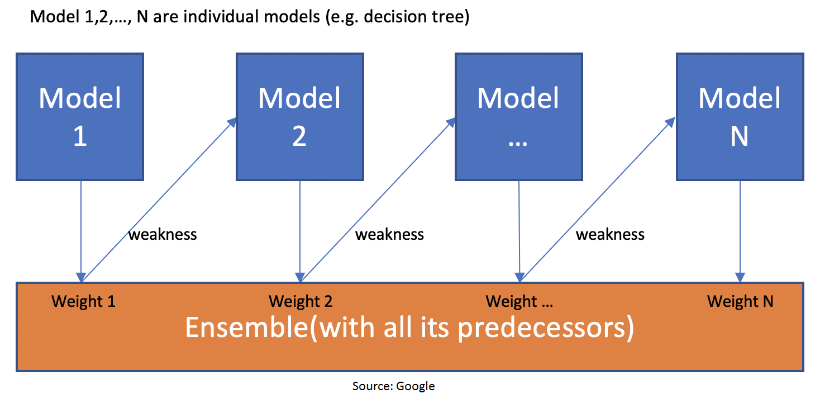

the first model is made and errors from the first model are noted by the algorithm. The record which is incorrectly classified is used as input for the next model. This process is repeated until the specified condition is met. As you can see in the figure, there are ‘n’ number of models made by taking the errors from the previous model. This is how boosting works. The models 1,2, 3,…, N are individual models that can be known as decision trees. All types of boosting models work on the same principle. 

Since we now know the boosting principle, it will be easy to understand the AdaBoost algorithm. Let’s dive into AdaBoost’s working. When the random forest is used, the algorithm makes an ‘n’ number of trees. It makes proper trees that consist of a start node with several leaf nodes. Some trees might be bigger than others, but there is no fixed depth in a random forest. With AdaBoost, however, the algorithm only makes a node with two leaves, known as Stump.

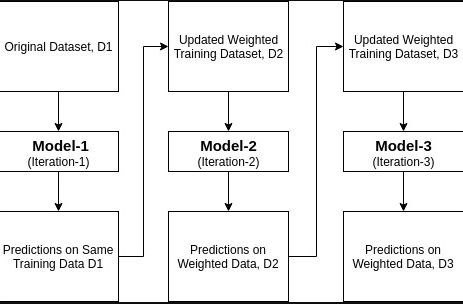

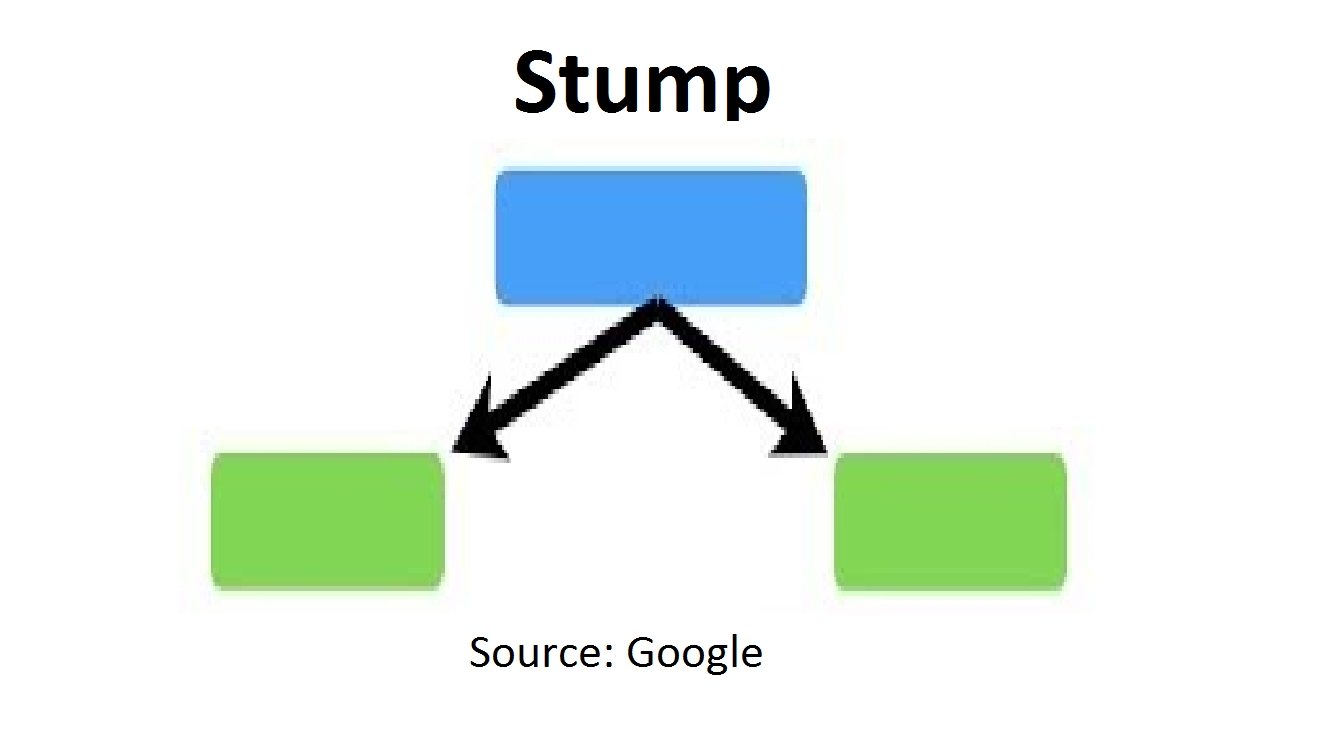

The figure here represents the stump. It can be seen clearly that it has only one node with two leaves. These stumps are weak learners and boosting techniques prefer this. The order of stumps is very important in AdaBoost. The error of the first stump influences how other stumps are made. Let’s understand this with an example.

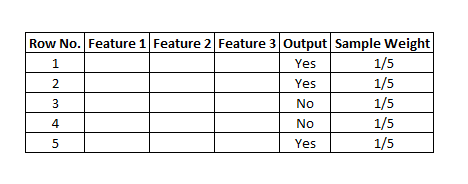

Here’s a sample dataset consisting of only three features where the output is in categorical form. The image shows the actual representation of the dataset. As the output is in binary/categorical form, it becomes a classification problem. In real life, the dataset can have any number of records and features in it. Let us consider 5 datasets for explanation purposes. The output is in categorical form, here in the form of Yes or No. All these records will be assigned a sample weight. The formula used for this is ‘W=1/N’ where N is the number of records. In this dataset, there are only 5 records, so the sample weight becomes 1/5 initially. Every record gets the same weight. In this case, it’s 1/5. 

## Step 1 – Creating the First Base Learner

To create the first learner, the algorithm takes the first feature, i.e., feature 1 and creates the first stump, f1. It will create the same number of stumps as the number of features. In the case below, it will create 3 stumps as there are only 3 features in this dataset. From these stumps, it will create three decision trees. This process can be called the stumps-base learner model. Out of these 3 models, the algorithm selects only one. Two properties are considered while selecting a base learner – Gini and Entropy. We must calculate Gini or Entropy the same way it is calculated for decision trees. The stump with the least value will be the first base learner. In the figure below, all the 3 stumps can be made with 3 features. The number below the leaves represents the correctly and incorrectly classified records. By using these records, the Gini or Entropy index is calculated. The stump that has the least Entropy or Gini will be selected as the base learner. Let’s assume that the entropy index is the least for stump 1. So, let’s take stump 1, i.e., feature 1 as our first base learner.

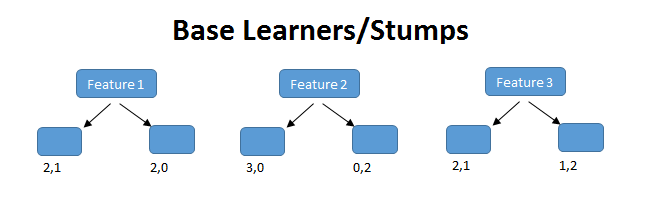

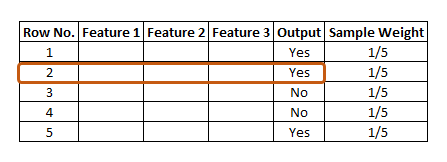

Here, feature (f1) has classified 2 records correctly and 1 incorrectly. The row in the figure that is marked red is incorrectly classified. For this, we will be calculating the total error.

## Step 2 – Calculating the Total Error (TE)

The total error is the sum of all the errors in the classified record for sample weights. In our case, there is only 1 error, so 

Total Error (TE) = 1/5.

#Step 3 – Calculating Performance of the Stump

Formula for calculating Performance of the Stump is: –

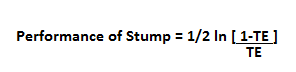

where, ln is natural log and TE is Total Error.


In our case, TE is 1/5. By substituting the value of total error in the above formula and solving it, we get the value for the performance of the stump as 0.693. Why is it necessary to calculate the TE and performance of a stump? The answer is, we must update the sample weight before proceeding to the next model or stage because if the same weight is applied, the output received will be from the first model. In boosting, only the wrong records/incorrectly classified records would get more preference than the correctly classified records. Thus, only the wrong records from the decision tree/stump are passed on to another stump. Whereas, in AdaBoost, both records were allowed to pass and the wrong records are repeated more than the correct ones. We must increase the weight for the wrongly classified records and decrease the weight for the correctly classified records. In the next step, we will be updating the weights based on the performance of the stump.

## Step 4 – Updating Weights

For incorrectly classified records, the formula for updating weights is:

**New Sample Weight = Sample Weight * e^(Performance)**

In our case Sample weight = 1/5 so, 1/5 e^ (0.693) = 0.399

For correctly classified records, we use the same formula with the performance value being negative. This leads the weight for correctly classified records to be reduced as compared to the incorrectly classified ones. The formula is:

**New Sample Weight = Sample Weight * e^- (Performance)**

**Putting the values, 1/5 * e^-(0.693) = 0.100** 

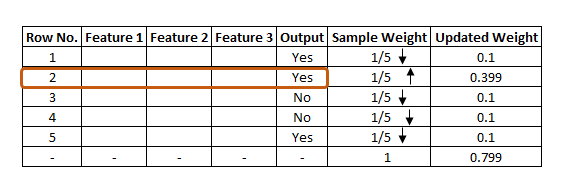

The updated weight for all the records can be seen in the figure. As is known, the total sum of all the weights should be 1. In this case, it is seen that the total updated weight of all the records is not 1, it’s 0.799. To bring the sum to 1, every updated weight must be divided by the total sum of updated weight. For example, if our updated weight is 0.399 and we divide this by 0.799, i.e. 0.399/0.799=0.50. 

0.50 can be known as the normalized weight. In the below figure, we can see all the normalized weight and their sum is approximately 1.

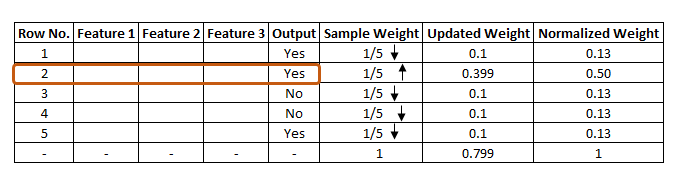

# Step 5 – Creating a New Dataset

Now, it’s time to create a new dataset from our previous one. In the new dataset, the frequency of incorrectly classified records will be more than the correct ones. The new dataset has to be created using and considering the normalized weights. It will probably select the wrong records for training purposes. That will be the second decision tree/stump. To make a new dataset based on normalized weight, the algorithm will divide it into buckets.

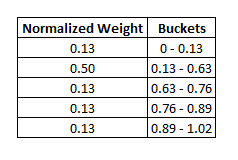

So, our first bucket is from 0 – 0.13, second will be from 0.13 – 0.63(0.13+0.50), third will be from 0.63 – 0.76(0.63+0.13), and so on. After this the algorithm will run 5 iterations to select different records from the older dataset. Suppose in the 1st iteration, the algorithm will take a random value 0.46 to see which bucket that value falls into and select that record in the new dataset. It will again select a random value, see which bucket it is in and select that record for the new dataset. The same process is repeated 5 times. 

There is a high probability for wrong records to get selected several times. This will form the new dataset. It can be seen in the image below that row number 2 has been selected multiple times from the older dataset as that row is incorrectly classified in the previous one. 

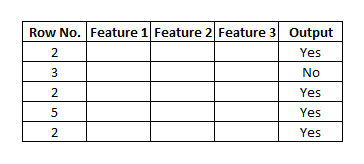


Based on this new dataset, the algorithm will create a new decision tree/stump and it will repeat the same process from step 1 till it sequentially passes through all stumps and finds that there is less error as compared to normalized weight that we had in the initial stage.

## How Does the Algorithm Decide Output for Test Data?

Suppose with the above dataset, the algorithm constructed 3 decision trees or stumps. The test dataset will pass through all the stumps which have been constructed by the algorithm. While passing through the 1st stump, the output it produces is 1. Passing through the 2nd stump, the output generated once again is 1. While passing through the 3rd stump it gives the output as 0. In the AdaBoost algorithm too, the majority of votes take place between the stumps, in the same way as in random trees. In this case, the final output will be 1. This is how the output with test data is decided. 

## How to Code AdaBoost in Python with Sklearn



In [1]:
import pandas as pd
df=pd.read_csv('../input/iris-data-set/Iris.csv')

In [2]:
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape

(150, 6)

In [4]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Species']=lb.fit_transform(df.Species)

In [7]:
df.head(10)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0
5,6,5.4,3.9,1.7,0.4,0
6,7,4.6,3.4,1.4,0.3,0
7,8,5.0,3.4,1.5,0.2,0
8,9,4.4,2.9,1.4,0.2,0
9,10,4.9,3.1,1.5,0.1,0


In [8]:
df.iloc[:,-1]

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 150, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(df.iloc[ :,0:-1],df.iloc[:,-1],test_size=0.3,random_state=52)

# **Build the Adaboost model**

In [10]:
from sklearn.ensemble import AdaBoostClassifier
abc=AdaBoostClassifier(n_estimators=50,learning_rate=1,random_state=52)
model1=abc.fit(Xtrain,ytrain)

In [11]:
ypred=abc.predict(Xtest)

# Evaulate model

In [12]:
from sklearn.metrics import accuracy_score
print('Adabost CLassifier Model Accuracy Score',accuracy_score(ypred,ypred))

Adabost CLassifier Model Accuracy Score 1.0


# SVC

In [13]:
from sklearn.svm import SVC
svc=SVC(probability=True,kernel='linear')
adb=AdaBoostClassifier(n_estimators=50,base_estimator=svc,learning_rate=1,random_state=52)
model2=adb.fit(Xtrain,ytrain)

In [14]:
ypred2=model2.predict(Xtest)

In [15]:
accuracy_score(ypred2,ytest)

0.9777777777777777